# BCB Type1+Type2+Type3 Thresholds Tested on Type4

This notebook reads the `Type1 + Type2 + Type3/all -> Type4` threshold experiment, shows the learned threshold for each graph, then reconstructs the Type4 balanced chunks and reports metrics per chunk and overall.

In [1]:
from __future__ import annotations

import json
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "spectral_code").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spectral_code.evaluation.bcb_dataset import ClonePair
from spectral_code.evaluation.bcb_cross_type_generalization import (
    NON_CLONE_VARIANT,
    TEST_VARIANT,
    _features_manifest_for,
    _load_features_from_manifests,
    _load_non_clone_pairs,
    _load_positive_pairs,
)
from spectral_code.evaluation.tuning import (
    PrecomputedSpectralModel,
    _classification_metrics,
    _decision_threshold,
    _filter_pairs_with_features,
    _filter_pairs_with_graph_features,
    _scores_at_or_above_threshold,
)
from spectral_code.utils.dataset_paths import OUTPUTS_ROOT

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

OUTPUT_ROOT = OUTPUTS_ROOT / "bcb" / "type123_to_type4"
REPORTS_DIR = OUTPUT_ROOT / "reports"
SUMMARY_JSON = REPORTS_DIR / "type123_threshold_test_type4_summary.json"
RESULTS_CSV = REPORTS_DIR / "type123_threshold_test_type4_results.csv"

for required in [SUMMARY_JSON, RESULTS_CSV]:
    if not required.exists():
        raise FileNotFoundError(f"Required experiment artifact not found: {required}")

print("Summary:", SUMMARY_JSON)
print("Results:", RESULTS_CSV)

c:\Users\koush\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Summary: C:\Users\koush\PyProjects\spectrals\outputs\bcb\type123_to_type4\reports\type123_threshold_test_type4_summary.json
Results: C:\Users\koush\PyProjects\spectrals\outputs\bcb\type123_to_type4\reports\type123_threshold_test_type4_results.csv


## Learned Thresholds

In [2]:
summary = json.loads(SUMMARY_JSON.read_text(encoding="utf-8"))
results_df = pd.read_csv(RESULTS_CSV)

threshold_cols = [
    "graph_type", "metric", "k_eigen", "metric_parameters",
    "best_threshold", "decision_threshold",
    "train_pairs", "train_positive_pairs", "train_negative_pairs",
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_auc",
    "test_pairs", "test_positive_pairs", "test_negative_pairs",
    "test_accuracy", "test_precision", "test_recall", "test_f1", "test_auc",
]
threshold_df = results_df[[col for col in threshold_cols if col in results_df.columns]].copy()
threshold_df = threshold_df.sort_values(["graph_type", "metric", "k_eigen"]).reset_index(drop=True)

display(pd.DataFrame([
    {"item": "train variants", "value": ", ".join(map(str, summary.get("train_variants", [])))},
    {"item": "test variant", "value": summary.get("test_variant")},
    {"item": "non-clone variant", "value": summary.get("non_clone_variant")},
    {"item": "optimize for", "value": summary.get("optimize_for")},
    {"item": "seed", "value": summary.get("seed")},
]))
display(threshold_df)

,item,value
0,train variants,"1, 2, 3/all"
1,test variant,4
2,non-clone variant,non_clone
3,optimize for,f1
4,seed,42


,graph_type,metric,k_eigen,metric_parameters,best_threshold,decision_threshold,train_pairs,train_positive_pairs,train_negative_pairs,train_accuracy,train_precision,train_recall,train_f1,train_auc,test_pairs,test_positive_pairs,test_negative_pairs,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,ast,pss,full,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",0.648762,0.648762,311888,155944,155944,0.836316,0.796742,0.902997,0.846549,0.931997,1878872,939436,939436,0.637272,0.686622,0.505051,0.582004,0.726350
1,cfg,pss,full,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",0.623136,0.623136,311888,155944,155944,0.730208,0.677130,0.880034,0.765362,0.856841,1878872,939436,939436,0.639963,0.624809,0.700670,0.660569,0.709042
2,cpg,pss,full,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",0.699541,0.699541,311888,155944,155944,0.792695,0.772814,0.829131,0.799983,0.891005,1878872,939436,939436,0.587167,0.632208,0.416823,0.502405,0.648574
3,ddg,pss,full,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",0.598684,0.598684,311871,155944,155927,0.779601,0.771605,0.794356,0.782815,0.859684,1878701,939356,939345,0.568202,0.613048,0.369864,0.461373,0.585987
4,pdg,pss,full,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",0.605702,0.605702,311888,155944,155944,0.789848,0.784456,0.799325,0.791821,0.872272,1878872,939436,939436,0.560834,0.608983,0.339934,0.436316,0.587701


In [3]:
train_selection = summary.get("train_pair_selection", {})
test_selection = summary.get("test_pair_selection", {})
display(pd.DataFrame(test_selection.get("chunks", [])))
display(pd.DataFrame([
    {"split": "train", **{k: v for k, v in train_selection.items() if k != "chunks"}},
    {"split": "test", **{k: v for k, v in test_selection.items() if k != "chunks"}},
]))

,chunk,positive_pairs,negative_pairs,unique_negative_pairs,total_pairs
0,1,260708,260708,260708,521416
1,2,260708,260708,260708,521416
2,3,260708,260708,260708,521416
3,4,157312,157312,157312,314624


,split,enabled,reason,seed,input_pairs,input_positive_pairs,input_negative_pairs,selected_pairs,selected_positive_pairs,selected_negative_pairs,unique_selected_negative_pairs,dropped_positive_pairs,dropped_negative_pairs,chunk_count
0,train,True,sample_non_clones_to_clone_count,42,416652,155944,260708,311888,155944,155944,155944,0,104764,1
1,test,True,chunk_clones_against_reused_non_clone_pool,43,1200144,939436,260708,1878872,939436,939436,260708,0,0,4


## Rebuild Type4 Chunks

In [4]:
def rebuild_balanced_chunks(
    positive_pairs: list[ClonePair],
    negative_pairs: list[ClonePair],
    *,
    seed: int,
) -> tuple[list[list[ClonePair]], list[dict]]:
    rng = random.Random(seed)
    shuffled_positives = list(positive_pairs)
    shuffled_negatives = list(negative_pairs)
    rng.shuffle(shuffled_positives)
    rng.shuffle(shuffled_negatives)

    chunks: list[list[ClonePair]] = []
    chunk_rows: list[dict] = []

    if len(shuffled_negatives) >= len(shuffled_positives):
        pos_chunk = shuffled_positives
        neg_chunk = shuffled_negatives[:len(pos_chunk)]
        chunk_pairs = pos_chunk + neg_chunk
        rng.shuffle(chunk_pairs)
        chunks.append(chunk_pairs)
        chunk_rows.append({
            "chunk": 1,
            "positive_pairs": len(pos_chunk),
            "negative_pairs": len(neg_chunk),
            "unique_negative_pairs": len({(pair.left_id, pair.right_id) for pair in neg_chunk}),
            "total_pairs": len(chunk_pairs),
        })
    else:
        chunk_size = len(shuffled_negatives)
        for chunk_index, start in enumerate(range(0, len(shuffled_positives), chunk_size), start=1):
            stop = min(start + chunk_size, len(shuffled_positives))
            pos_chunk = shuffled_positives[start:stop]
            if len(pos_chunk) == len(shuffled_negatives):
                neg_chunk = list(shuffled_negatives)
            else:
                neg_chunk = rng.sample(shuffled_negatives, len(pos_chunk))
            chunk_pairs = pos_chunk + neg_chunk
            rng.shuffle(chunk_pairs)
            chunks.append(chunk_pairs)
            chunk_rows.append({
                "chunk": chunk_index,
                "positive_pairs": len(pos_chunk),
                "negative_pairs": len(neg_chunk),
                "unique_negative_pairs": len({(pair.left_id, pair.right_id) for pair in neg_chunk}),
                "total_pairs": len(chunk_pairs),
            })
    return chunks, chunk_rows

test_seed = int(test_selection.get("seed", int(summary.get("seed", 42)) + 1))
type4_positive_pairs = _load_positive_pairs(TEST_VARIANT)
non_clone_pairs = _load_non_clone_pairs()
test_chunks, rebuilt_chunk_rows = rebuild_balanced_chunks(type4_positive_pairs, non_clone_pairs, seed=test_seed)

rebuilt_chunks_df = pd.DataFrame(rebuilt_chunk_rows)
display(rebuilt_chunks_df)

expected_chunks_df = pd.DataFrame(test_selection.get("chunks", []))
if not expected_chunks_df.empty:
    compare_cols = ["chunk", "positive_pairs", "negative_pairs", "unique_negative_pairs", "total_pairs"]
    if not rebuilt_chunks_df[compare_cols].equals(expected_chunks_df[compare_cols]):
        raise AssertionError("Rebuilt Type4 chunks do not match the experiment summary metadata.")

all_test_pairs = [pair for chunk in test_chunks for pair in chunk]
print(f"Rebuilt {len(test_chunks)} Type4 chunks with {len(all_test_pairs):,} pair evaluations.")

,chunk,positive_pairs,negative_pairs,unique_negative_pairs,total_pairs
0,1,260708,260708,260708,521416
1,2,260708,260708,260708,521416
2,3,260708,260708,260708,521416
3,4,157312,157312,157312,314624


Rebuilt 4 Type4 chunks with 1,878,872 pair evaluations.


## Score Each Type4 Chunk

In [5]:
test_manifests = [_features_manifest_for(TEST_VARIANT), _features_manifest_for(NON_CLONE_VARIANT)]
test_features = _load_features_from_manifests(test_manifests, all_test_pairs)
print(f"Loaded spectral features for {len(test_features):,} Type4/non-clone methods used in rebuilt chunks.")

Loading feature shards:  98%|█████████▊| 55/56 [00:02<00:00, 23.19shard/s]


Loaded spectral features for 69,082 Type4/non-clone methods used in rebuilt chunks.


In [6]:
def confusion_counts(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict:
    preds = _scores_at_or_above_threshold(scores, threshold).astype(int)
    labels = np.asarray(labels, dtype=int)
    return {
        "tp": int(np.sum((labels == 1) & (preds == 1))),
        "fp": int(np.sum((labels == 0) & (preds == 1))),
        "tn": int(np.sum((labels == 0) & (preds == 0))),
        "fn": int(np.sum((labels == 1) & (preds == 0))),
    }

def metrics_from_confusion(tp: int, fp: int, tn: int, fn: int) -> dict:
    total = tp + fp + tn + fn
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    accuracy = (tp + tn) / total if total else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

def k_value_from_row(value):
    text = str(value).strip().lower()
    if text in {"full", "none", "nan", ""}:
        return None
    return int(float(value))

chunk_metric_rows = []
final_metric_rows = []
score_bins = np.linspace(0.0, 1.0, 71)
score_histograms: dict[tuple[str, str, str, int], np.ndarray] = {}
score_start = time.perf_counter()

for _, config in tqdm(results_df.iterrows(), total=len(results_df), desc="Configs"):
    graph_type = str(config["graph_type"])
    metric = str(config["metric"])
    k_value = k_value_from_row(config.get("k_eigen", "full"))
    k_display = "full" if k_value is None else k_value
    k_hist_label = str(k_display)
    threshold = float(config["best_threshold"])
    model = PrecomputedSpectralModel(test_features, graph_type, k_value, threshold, metric)

    combined_scores = []
    combined_labels = []
    aggregate_confusion = {"tp": 0, "fp": 0, "tn": 0, "fn": 0}

    for chunk_index, chunk_pairs in enumerate(test_chunks, start=1):
        feature_pairs = _filter_pairs_with_features(chunk_pairs, test_features)
        graph_pairs = _filter_pairs_with_graph_features(feature_pairs, test_features, graph_type, show_progress=False)
        scores = np.asarray([model.score_pair(pair) for pair in tqdm(graph_pairs, desc=f"{graph_type}/{metric} chunk {chunk_index}", unit="pair", leave=False)], dtype=np.float64)
        labels = np.asarray([pair.label for pair in graph_pairs], dtype=np.int8)

        metrics = _classification_metrics(labels, scores, threshold) if len(labels) else {
            "accuracy": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0, "auc": 0.0
        }
        confusion = confusion_counts(labels, scores, threshold) if len(labels) else {"tp": 0, "fp": 0, "tn": 0, "fn": 0}
        for key in aggregate_confusion:
            aggregate_confusion[key] += confusion[key]

        combined_scores.append(scores)
        combined_labels.append(labels)

        for label_value in [0, 1]:
            label_scores = scores[labels == label_value]
            hist_key = (graph_type, metric, k_hist_label, label_value)
            if hist_key not in score_histograms:
                score_histograms[hist_key] = np.zeros(len(score_bins) - 1, dtype=np.int64)
            if label_scores.size:
                score_histograms[hist_key] += np.histogram(np.clip(label_scores, 0.0, 1.0), bins=score_bins)[0]

        chunk_metric_rows.append({
            "chunk": chunk_index,
            "graph_type": graph_type,
            "metric": metric,
            "k_eigen": "full" if k_value is None else k_value,
            "threshold": threshold,
            "input_pairs": int(len(chunk_pairs)),
            "valid_pairs": int(len(labels)),
            "positive_pairs": int(np.sum(labels == 1)),
            "negative_pairs": int(np.sum(labels == 0)),
            **confusion,
            "accuracy": float(metrics["accuracy"]),
            "precision": float(metrics["precision"]),
            "recall": float(metrics["recall"]),
            "f1": float(metrics["f1"]),
            "auc": float(metrics["auc"]),
        })

    combined_scores_arr = np.concatenate(combined_scores) if combined_scores else np.array([], dtype=np.float64)
    combined_labels_arr = np.concatenate(combined_labels) if combined_labels else np.array([], dtype=np.int8)
    final_metrics = _classification_metrics(combined_labels_arr, combined_scores_arr, threshold) if len(combined_labels_arr) else {
        "accuracy": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0, "auc": 0.0
    }
    aggregate_metrics = metrics_from_confusion(**aggregate_confusion)

    final_metric_rows.append({
        "graph_type": graph_type,
        "metric": metric,
        "k_eigen": "full" if k_value is None else k_value,
        "threshold": threshold,
        "valid_pairs": int(len(combined_labels_arr)),
        "positive_pairs": int(np.sum(combined_labels_arr == 1)),
        "negative_pairs": int(np.sum(combined_labels_arr == 0)),
        **aggregate_confusion,
        "accuracy_from_parts": float(aggregate_metrics["accuracy"]),
        "precision_from_parts": float(aggregate_metrics["precision"]),
        "recall_from_parts": float(aggregate_metrics["recall"]),
        "f1_from_parts": float(aggregate_metrics["f1"]),
        "accuracy": float(final_metrics["accuracy"]),
        "precision": float(final_metrics["precision"]),
        "recall": float(final_metrics["recall"]),
        "f1": float(final_metrics["f1"]),
        "auc": float(final_metrics["auc"]),
    })

chunk_metrics_df = pd.DataFrame(chunk_metric_rows)
final_metrics_df = pd.DataFrame(final_metric_rows).sort_values(["accuracy", "f1"], ascending=False).reset_index(drop=True)
print(f"Scored chunk metrics in {time.perf_counter() - score_start:.1f}s")
display(chunk_metrics_df)
display(final_metrics_df)

Configs:  60%|██████    | 3/5 [09:15<06:12, 186.31s/it]

[*] DDG: dropped 48 pairs with missing/all-zero spectra.


[*] DDG: dropped 49 pairs with missing/all-zero spectra.


[*] DDG: dropped 48 pairs with missing/all-zero spectra.


[*] DDG: dropped 26 pairs with missing/all-zero spectra.


Configs: 100%|██████████| 5/5 [15:29<00:00, 185.88s/it]

Scored chunk metrics in 929.4s


,chunk,graph_type,metric,k_eigen,threshold,input_pairs,valid_pairs,positive_pairs,negative_pairs,tp,fp,tn,fn,accuracy,precision,recall,f1,auc
0,1,cfg,pss,full,0.623136,521416,521416,260708,260708,182413,109662,151046,78295,0.639526,0.624542,0.699683,0.659980,0.708432
1,2,cfg,pss,full,0.623136,521416,521416,260708,260708,182892,109662,151046,77816,0.640444,0.625156,0.701520,0.661141,0.709240
2,3,cfg,pss,full,0.623136,521416,521416,260708,260708,182683,109662,151046,78025,0.640044,0.624888,0.700719,0.660635,0.709237
3,4,cfg,pss,full,0.623136,314624,314624,157312,157312,110247,66277,91035,47065,0.639754,0.624544,0.700817,0.660486,0.709404
4,1,ast,pss,full,0.648762,521416,521416,260708,260708,131592,60059,200649,129116,0.637190,0.686623,0.504749,0.581803,0.726515
5,2,ast,pss,full,0.648762,521416,521416,260708,260708,131644,60059,200649,129064,0.637290,0.686708,0.504948,0.581966,0.726460
6,3,ast,pss,full,0.648762,521416,521416,260708,260708,131656,60059,200649,129052,0.637313,0.686728,0.504994,0.582004,0.726045
7,4,ast,pss,full,0.648762,314624,314624,157312,157312,79571,36370,120942,77741,0.637310,0.686306,0.505816,0.582398,0.726402
8,1,cpg,pss,full,0.699541,521416,521416,260708,260708,108752,63176,197532,151956,0.587408,0.632544,0.417141,0.502741,0.648342
9,2,cpg,pss,full,0.699541,521416,521416,260708,260708,108557,63176,197532,152151,0.587034,0.632127,0.416393,0.502066,0.648784


,graph_type,metric,k_eigen,threshold,valid_pairs,positive_pairs,negative_pairs,tp,fp,tn,fn,accuracy_from_parts,precision_from_parts,recall_from_parts,f1_from_parts,accuracy,precision,recall,f1,auc
0,cfg,pss,full,0.623136,1878872,939436,939436,658235,395263,544173,281201,0.639963,0.624809,0.700670,0.660569,0.639963,0.624809,0.700670,0.660569,0.709042
1,ast,pss,full,0.648762,1878872,939436,939436,474463,216547,722889,464973,0.637272,0.686622,0.505051,0.582004,0.637272,0.686622,0.505051,0.582004,0.726350
2,cpg,pss,full,0.699541,1878872,939436,939436,391579,227804,711632,547857,0.587167,0.632208,0.416823,0.502405,0.587167,0.632208,0.416823,0.502405,0.648574
3,ddg,pss,full,0.598684,1878701,939356,939345,347434,219298,720047,591922,0.568202,0.613048,0.369864,0.461373,0.568202,0.613048,0.369864,0.461373,0.585987
4,pdg,pss,full,0.605702,1878872,939436,939436,319346,205046,734390,620090,0.560834,0.608983,0.339934,0.436316,0.560834,0.608983,0.339934,0.436316,0.587701


## Compare Recomputed Final Metrics with Saved Summary

In [7]:
saved_test_cols = [
    "graph_type", "metric", "k_eigen", "best_threshold",
    "test_accuracy", "test_precision", "test_recall", "test_f1", "test_auc",
]
comparison_df = final_metrics_df.merge(
    results_df[[col for col in saved_test_cols if col in results_df.columns]],
    on=["graph_type", "metric", "k_eigen"],
    how="left",
)
for metric_name in ["accuracy", "precision", "recall", "f1", "auc"]:
    comparison_df[f"{metric_name}_delta_vs_saved"] = comparison_df[metric_name] - comparison_df[f"test_{metric_name}"]

display(comparison_df.sort_values(["accuracy", "f1"], ascending=False))

,graph_type,metric,k_eigen,threshold,valid_pairs,positive_pairs,negative_pairs,tp,fp,tn,fn,accuracy_from_parts,precision_from_parts,recall_from_parts,f1_from_parts,accuracy,precision,recall,f1,auc,best_threshold,test_accuracy,test_precision,test_recall,test_f1,test_auc,accuracy_delta_vs_saved,precision_delta_vs_saved,recall_delta_vs_saved,f1_delta_vs_saved,auc_delta_vs_saved
0,cfg,pss,full,0.623136,1878872,939436,939436,658235,395263,544173,281201,0.639963,0.624809,0.700670,0.660569,0.639963,0.624809,0.700670,0.660569,0.709042,0.623136,0.639963,0.624809,0.700670,0.660569,0.709042,0.0,0.0,0.000000e+00,0.0,0.0
1,ast,pss,full,0.648762,1878872,939436,939436,474463,216547,722889,464973,0.637272,0.686622,0.505051,0.582004,0.637272,0.686622,0.505051,0.582004,0.726350,0.648762,0.637272,0.686622,0.505051,0.582004,0.726350,0.0,0.0,0.000000e+00,0.0,0.0
2,cpg,pss,full,0.699541,1878872,939436,939436,391579,227804,711632,547857,0.587167,0.632208,0.416823,0.502405,0.587167,0.632208,0.416823,0.502405,0.648574,0.699541,0.587167,0.632208,0.416823,0.502405,0.648574,0.0,0.0,5.551115e-17,0.0,0.0
3,ddg,pss,full,0.598684,1878701,939356,939345,347434,219298,720047,591922,0.568202,0.613048,0.369864,0.461373,0.568202,0.613048,0.369864,0.461373,0.585987,0.598684,0.568202,0.613048,0.369864,0.461373,0.585987,0.0,0.0,5.551115e-17,0.0,0.0
4,pdg,pss,full,0.605702,1878872,939436,939436,319346,205046,734390,620090,0.560834,0.608983,0.339934,0.436316,0.560834,0.608983,0.339934,0.436316,0.587701,0.605702,0.560834,0.608983,0.339934,0.436316,0.587701,0.0,0.0,0.000000e+00,0.0,0.0


## Type4 Pair Score Distributions by Label


,graph_type,metric,k_eigen,threshold,accuracy,precision,recall,f1,auc
0,cfg,pss,full,0.623136,0.639963,0.624809,0.700670,0.660569,0.709042
1,ast,pss,full,0.648762,0.637272,0.686622,0.505051,0.582004,0.726350
2,cpg,pss,full,0.699541,0.587167,0.632208,0.416823,0.502405,0.648574
3,ddg,pss,full,0.598684,0.568202,0.613048,0.369864,0.461373,0.585987
4,pdg,pss,full,0.605702,0.560834,0.608983,0.339934,0.436316,0.587701


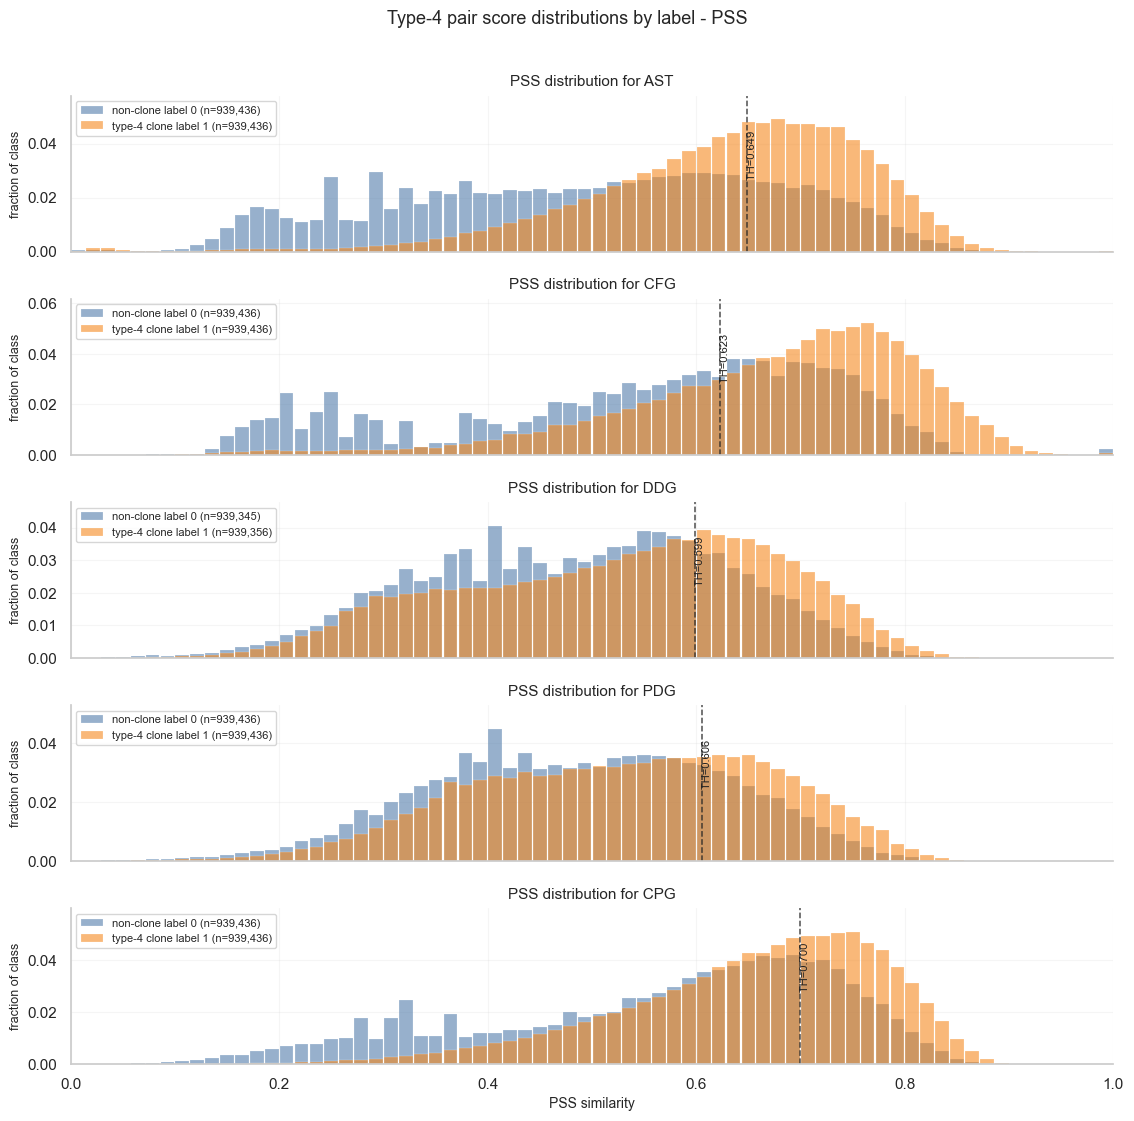

In [8]:
def graph_order_from(df: pd.DataFrame) -> list[str]:
    canonical = ["ast", "cfg", "ddg", "pdg", "cpg"]
    available = set(df["graph_type"].dropna().astype(str).unique())
    ordered = [graph for graph in canonical if graph in available]
    ordered.extend(sorted(available - set(ordered)))
    return ordered


def plot_type4_distribution_like_type4_notebook(metric: str, k_label: str, configs_df: pd.DataFrame) -> None:
    graph_types = graph_order_from(configs_df)
    centers = (score_bins[:-1] + score_bins[1:]) / 2
    width = float(score_bins[1] - score_bins[0])
    fig, axes = plt.subplots(
        len(graph_types),
        1,
        figsize=(11.5, max(3.0, 2.25 * len(graph_types))),
        sharex=True,
        squeeze=False,
    )
    colors = {0: "#4C78A8", 1: "#F58518"}
    labels = {0: "non-clone label 0", 1: "type-4 clone label 1"}

    for row, graph in enumerate(graph_types):
        ax = axes[row][0]
        max_y = 0.0
        for label in [0, 1]:
            counts = score_histograms.get(
                (str(graph), str(metric), str(k_label), label),
                np.zeros(len(score_bins) - 1, dtype=np.int64),
            )
            total = int(counts.sum())
            fraction = counts / total if total else counts.astype(float)
            max_y = max(max_y, float(fraction.max()) if fraction.size else 0.0)
            ax.bar(
                centers,
                fraction,
                width=width * 0.92,
                color=colors[label],
                alpha=0.58,
                edgecolor="white",
                linewidth=0.25,
                label=f"{labels[label]} (n={total:,})",
            )

        threshold_row = configs_df[
            (configs_df["graph_type"].astype(str) == str(graph))
            & (configs_df["metric"].astype(str) == str(metric))
            & (configs_df["k_eigen"].astype(str) == str(k_label))
        ]
        if not threshold_row.empty:
            threshold = float(threshold_row.iloc[0]["threshold"])
            ax.axvline(threshold, color="#222222", linestyle="--", linewidth=1.1, alpha=0.8)
            ax.text(
                threshold,
                max_y * 0.92 if max_y else 0.02,
                f"  TH={threshold:.3f}",
                rotation=90,
                va="top",
                ha="left",
                fontsize=8,
                color="#222222",
            )

        ax.set_title(f"{metric.upper()} distribution for {graph.upper()}", fontsize=11, pad=7)
        ax.set_ylabel("fraction of class", fontsize=9)
        ax.set_ylim(0, max(0.04, max_y * 1.18))
        ax.grid(True, axis="both", alpha=0.18, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(loc="upper left", fontsize=8, frameon=True)

    axes[-1][0].set_xlabel(f"{metric.upper()} similarity", fontsize=10)
    axes[-1][0].set_xlim(0, 1)
    fig.suptitle(f"Type-4 pair score distributions by label - {metric.upper()}", y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()


plot_configs_df = final_metrics_df.copy()
plot_configs_df["k_eigen"] = plot_configs_df["k_eigen"].astype(str)

display(plot_configs_df[["graph_type", "metric", "k_eigen", "threshold", "accuracy", "precision", "recall", "f1", "auc"]])

for metric_name in sorted(plot_configs_df["metric"].dropna().astype(str).unique()):
    metric_df = plot_configs_df[plot_configs_df["metric"].astype(str) == metric_name]
    for k_label in sorted(metric_df["k_eigen"].dropna().astype(str).unique(), key=lambda value: (value != "full", value)):
        plot_type4_distribution_like_type4_notebook(
            metric_name,
            k_label,
            metric_df[metric_df["k_eigen"].astype(str) == k_label],
        )
